## Transformer Types

Encoder-only: reads the whole input at once and builds contextual representations using bidirectional attention. Good for understanding tasks like classification, tagging, and search. (aka: understand text)

Decoder-only: reads tokens left-to-right with a causal mask, so each token sees only earlier tokens. Good for generation tasks like next-word prediction and chat. (aka: generate text)

**Encoder-decoder: the encoder first understands the input, then the decoder generates output token by token while attending to the encoder output. Good for input-to-output tasks like translation and summarization. (aka: transform one text into another)**

# 7. Forward and Backward in an Encoder-Decoder Transformer

This notebook demonstrates an encoder-decoder transformer, which uses both bidirectional attention (in the encoder) and causal attention + cross-attention (in the decoder).

We will build each class separately for learning purposes and then run a tiny sequence-to-sequence training example (e.g., translation).

In [1]:
# importing necessary Python libraries
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence

# try argument to check whether matplotlib.pyplot is installed and imported
try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except ImportError:
    plt = None
    HAS_MATPLOTLIB = False

# defining manual_seed to ensure reproducability in 'randomness'
torch.manual_seed(42)

## Step 1: Token and Positional Embedding

An encoder-decoder transformer converts both input (source) and output (target) token ids into vectors and adds positional embeddings.

In [2]:
# Definining Word Embedding class
#   to process token representation (token + position)
class TokenAndPositionEmbedding(nn.Module):
    # initializing..
    def __init__(self, vocab_size, d_model, max_seq_len):
        super().__init__()
        # initializing vectorized token and position embedding
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(max_seq_len, d_model)

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        batch_size, seq_len = x.shape

        # Convert token ids into dense vectors
        token_vectors = self.token_embedding(x)

        # Create position ids like [0, 1, 2, ..., seq_len-1]
        positions = torch.arange(seq_len, device=x.device)
        position_vectors = self.position_embedding(positions)

        # Broadcasting merge/adds position information
        return token_vectors + position_vectors

## Step 2: Multi-Head Attention (Self and Cross Attention)

We define a general Multi-Head Attention module that can handle:
1. **Encoder Self-Attention**: No mask.
2. **Decoder Self-Attention**: Uses a causal mask so it only looks at past tokens.
3. **Cross-Attention**: The queries come from the decoder, but the keys and values come from the encoder output. No causal mask is needed here because the entire encoder output is available.

In [3]:
# Defining Multi-Head Attention class
class MultiHeadAttention(nn.Module):
    # initializing
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, 'd_model must be divisible by num_heads'

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        # linear projection space for Q, K, V and O
        self.query = nn.Linear(d_model, d_model)
        self.key = nn.Linear(d_model, d_model)
        self.value = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, d_model)

    def forward(self, q_x, k_x, v_x, mask=None):
        # For self-attention: q_x = k_x = v_x
        # For cross-attention: q_x comes from decoder, k_x and v_x come from encoder
        batch_size, seq_len_q, _ = q_x.shape
        _, seq_len_k, _ = k_x.shape

        # Project into Q, K, V vector space
        q = self.query(q_x)
        k = self.key(k_x)
        v = self.value(v_x)

        # Split and transpose for multi-head attention
        q = q.view(batch_size, seq_len_q, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(batch_size, seq_len_k, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(batch_size, seq_len_k, self.num_heads, self.head_dim).transpose(1, 2)

        # Compute raw attention scores (QK^T / sqrt(d_k))
        scores = q @ k.transpose(-2, -1) / math.sqrt(self.head_dim)

        # Apply causal mask if provided (used in decoder self-attention)
        if mask is not None:
            # We assume mask shape is (seq_len_q, seq_len_k)
            scores = scores.masked_fill(mask == 0, float('-inf'))

        # Softmax turns scores into attention weights
        attention_weights = F.softmax(scores, dim=-1)

        # Weighted sum of value vectors
        attended = attention_weights @ v

        # Merge heads back
        attended = attended.transpose(1, 2).contiguous().view(batch_size, seq_len_q, self.d_model)

        return self.out(attended)

## Step 3: Feed-Forward Network

The standard position-wise feed-forward network applied after attention.

In [4]:
# Defining Feed Forward Network class
class FeedForward(nn.Module):
    # initializing..
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.net(x)

## Step 4: Encoder Block and Decoder Block

The **Encoder Block**
   - self-attention (no mask) and
   - a feed-forward network.

The **Decoder Block**
   - masked self-attention,
      - (allowing the learnable vectorized token to talk another before to understand the context deeper before asking encoder's output K and V)
   - cross-attention (looking at the encoder's output)
      - (the queries know the context better from self-attention and asking to the K and V to get deeper more context as encoder's already processed the complete contextualized vectorized tokens while not telling the full actual answer), and
   - a feed-forward network.

In [5]:
# Defining EncoderBlock class
class EncoderBlock(nn.Module):
    def __init__(self, d_model, d_ff, num_heads, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)

        self.feed_forward = FeedForward(d_model, d_ff)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):
        # Self-attention (no mask)
        attn_out = self.attention(q_x=x, k_x=x, v_x=x)
        x = self.norm1(x + self.dropout1(attn_out))
        
        # Feed-forward
        ff_out = self.feed_forward(x)
        x = self.norm2(x + self.dropout2(ff_out))
        return x

# Defining DecoderBlock class
class DecoderBlock(nn.Module):
    def __init__(self, d_model, d_ff, num_heads, dropout=0.1):
        super().__init__()
        # Masked self-attention
        self.self_attention = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)

        # Cross-attention
        self.cross_attention = MultiHeadAttention(d_model, num_heads)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout2 = nn.Dropout(dropout)

        # Feed-forward
        self.feed_forward = FeedForward(d_model, d_ff)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, enc_out, mask):
        # 1. Masked self-attention (causal mask)
        self_attn_out = self.self_attention(q_x=x, k_x=x, v_x=x, mask=mask)
        x = self.norm1(x + self.dropout1(self_attn_out))

        # 2. Cross-attention (query from decoder x, key/value from encoder enc_out)
        cross_attn_out = self.cross_attention(q_x=x, k_x=enc_out, v_x=enc_out)
        x = self.norm2(x + self.dropout2(cross_attn_out))

        # 3. Feed-forward
        ff_out = self.feed_forward(x)
        x = self.norm3(x + self.dropout3(ff_out))
        return x

## Step 5: Complete Encoder-Decoder Transformer

Combines everything.
- We pass the source sequence through the encoder, then
- pass the target sequence (shifted for teacher forcing) and
- the encoder output through the decoder.

In [6]:
# Definining EncoderDecoderTransformer class
class EncoderDecoderTransformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model, max_seq_len, d_ff, num_heads, num_layers, dropout=0.1):
        super().__init__()

        # Source and Target embeddings
        # src_embedding for encoder block
        self.src_embedding = TokenAndPositionEmbedding(src_vocab_size, d_model, max_seq_len)
        # tgt_embedding for decoder block
        self.tgt_embedding = TokenAndPositionEmbedding(tgt_vocab_size, d_model, max_seq_len)

        # Encoder and Decoder blocks
        self.encoder_blocks = nn.ModuleList([
            EncoderBlock(d_model, d_ff, num_heads, dropout) for _ in range(num_layers)
        ])
        
        self.decoder_blocks = nn.ModuleList([
            DecoderBlock(d_model, d_ff, num_heads, dropout) for _ in range(num_layers)
        ])

        # Final projection to target vocabulary size
        self.classifier = nn.Linear(d_model, tgt_vocab_size)

    def create_causal_mask(self, seq_len, device):
        # Lower triangular matrix for causal masking
        mask = torch.tril(torch.ones(seq_len, seq_len, device=device))
        return mask

    def forward(self, src, tgt):
        # 1. Encode source
        enc_out = self.src_embedding(src)
        for enc_block in self.encoder_blocks:
            enc_out = enc_block(enc_out)

        # 2. Decode target
        dec_out = self.tgt_embedding(tgt)
        seq_len_tgt = tgt.shape[1]
        mask = self.create_causal_mask(seq_len_tgt, tgt.device)

        for dec_block in self.decoder_blocks:
            dec_out = dec_block(dec_out, enc_out, mask)

        # normalization is not needed here, as the decoder block already
        # takes care on normalizing hidden representation before returning dec_out

        # 3. Project to vocabulary as prediction_score
        logits = self.classifier(dec_out)
        return logits

## Step 6: Data Pre-processing for Sequence-to-Sequence Example

This section prepares the toy translation dataset for training the Encoder-Decoder Transformer. The steps involve defining vocabularies, encoding sentences into numerical IDs, and padding sequences to ensure uniform length for batch processing.

1.  **Define Vocabularies**:
    *   `src_vocab`: Maps English words to unique integer IDs. Includes a `<PAD>` token for padding shorter sequences.
    *   `tgt_vocab`: Maps French words to unique integer IDs. Includes `<SOS>` (Start Of Sentence), `<EOS>` (End Of Sentence), and `<PAD>` tokens.
    *   `id_to_src` and `id_to_tgt`: Reverse mappings from IDs back to words for debugging and interpretation.

2.  **Prepare Sentence Pairs**:
    *   `pairs`: A small set of English-French sentence pairs is defined.
    *   `src_sentences`: Stores the source (English) sentences.
    *   `tgt_input_sentences`: Prepares the target (French) sentences for decoder input by prepending `<SOS>`.
    *   `target_sentences`: Prepares the target (French) sentences for loss calculation by appending `<EOS>`.

3.  **Convert Words to IDs and Pad Sequences**:
    *   The `encode_tokens` function converts a list of words into a list of their corresponding integer IDs using the defined vocabularies.
    *   `src_inputs`: Source sentences are converted to IDs and padded to the maximum source sequence length using `src_vocab['<PAD>']`.
    *   `tgt_inputs`: Target input sentences (with `<SOS>`) are converted to IDs and padded using `tgt_vocab['<PAD>']`.
    *   `targets`: Target output sentences (with `<EOS>`) are converted to IDs and padded using `tgt_vocab['<PAD>']`.
    *   `pad_sequence` ensures all sequences within a batch have the same length, which is crucial for tensor operations.

In [7]:
# 1. Define a slightly richer toy vocabulary (English -> French)
# src_vocab and tgt_vocab in (key -> word; value -> ID) array design due to the numerical indexing from head readable into creating ID for each word token.
#   Later, will be reverse mapping in id_to_src and id_to_tgt

#   src_vocab: Using '<PAD>' tag as placeholder to fill the shorter words token when embedding in matrix shape (rectangular shape)
src_vocab = {
    '<PAD>': 0,
    'the': 1, 'small': 2, 'cat': 3, 'sat': 4, 'on': 5, 'warm': 6, 'mat': 7,
    'happy': 8, 'dog': 9, 'ran': 10, 'to': 11, 'park': 12,
    'bird': 13, 'sang': 14, 'a': 15, 'soft': 16, 'song': 17,
}

#   tgt_vocab: Using '<SOS>' and '<EOS>' and '<PAD>' tag for
#       '<SOS>' indicates the starting word token
#       '<END>' indicates the ending word token
#       '<PAD>' placeholder to fill the shorter words token (similar usage as src_vocab)
tgt_vocab = {
    '<SOS>': 0, '<EOS>': 1, '<PAD>': 2,
    'le': 3, 'petit': 4, 'chat': 5, 'est': 6, 'assis': 7, 'sur': 8, 'tapis': 9, 'chaud': 10,
    'chien': 11, 'heureux': 12, 'a': 13, 'couru': 14, 'au': 15, 'parc': 16,
    'oiseau': 17, 'chante': 18, 'une': 19, 'chanson': 20, 'douce': 21,
}

# Capturing the whole full length size for src_vocab and tgt_vocab dataset
src_vocab_size, tgt_vocab_size = len(src_vocab), len(tgt_vocab)

# in dataset src_vocab and tgt_vocab dataset use:
#   key: value arrays as (key -> word; value -> ID token)
#   so id_to_src and id_to_tgt are done to reverse mapping the dataset
#       original vocab: (key -> word; value -> ID token)
#       reverse mapping (key -> ID token; value -> word)
#   Usage: for debugging, tracing, printing model outputs or inferencing
id_to_src = {v: k for k, v in src_vocab.items()}
id_to_tgt = {v: k for k, v in tgt_vocab.items()}

# encode tokens
#   uses for tokenization and numericalization process
#   essential for NN to learn in sequence in numerical input
#       it would return number of sequence in array [1, 2, 3]
#   Usage: convert words into numbers
#       ask where the tokens sequence for word
#       Example: ["small", "cat"] -> [2, 3]
def encode_tokens(tokens, vocab):
    return [vocab[token] for token in tokens]

# 2. Toy sentence pairs represented as actual words
#   Starting point on creating batch and sequences for data sample in tuple design
#       on mapping `src_vocab` and `tgt_vocab`
#   Usage: raw, un-processed collection of data sample that will be transformed
#       in later pre-processing steps
pairs = [
    (
        ['the', 'small', 'cat', 'sat', 'on', 'the', 'warm', 'mat'],
        ['le', 'petit', 'chat', 'est', 'assis', 'sur', 'le', 'tapis', 'chaud'],
    ),
    (
        ['the', 'happy', 'dog', 'ran', 'to', 'the', 'park'],
        ['le', 'chien', 'heureux', 'a', 'couru', 'au', 'parc'],
    ),
    (
        ['the', 'bird', 'sang', 'a', 'soft', 'song'],
        ['le', 'oiseau', 'a', 'chante', 'une', 'chanson', 'douce'],
    ),
]

# USAGE in list comprehension in Python
# Stores the `src` words from `pairs`
#   _ indicates to ignore the other variable (tgt)
src_sentences = [src for src, _ in pairs]

# Stores the `tgt` words from `pairs`
#   _ indicates to ignore the other vairable (src)
tgt_sentences = [tgt for _, tgt in pairs]

# Prepending for each batch in tgt_sentences with
#   `<SOS>` tag in the beginning
#   Usage: for decoder input in predicting first and next tokens
tgt_input_sentences = [['<SOS>', *tgt] for tgt in tgt_sentences]

# Appending for each batch in tgt_sentences with
#   `<EOS>` tag in the end
#   Usage: for calculation loss in comparing predicted and ground_truth
target_sentences = [tgt + ['<EOS>'] for tgt in tgt_sentences]

# Initializing in using tensor objects
# 3. Convert words to ids and pad each batch to a common length
#   pad_sequence() is used to fill the any short tokens will placeholder through defining special tag `<PAD>`
#       to ensure the tensor object in matrix shape (square or rectangular)
src_inputs = pad_sequence(
    # fills the token ID: word tokens in tensor object in for loops until words are finished
    [torch.tensor(encode_tokens(src, src_vocab), dtype=torch.long) for src in src_sentences],
    # indicates the dimension starts with batch_size instead of sequence_length, so it becomes (batch_size, seq_len)
    batch_first=True,
    # this is where tells pad_sequence() to fill placeholder for shorter sequence word tokens
    padding_value=src_vocab['<PAD>'],
)

tgt_inputs = pad_sequence(
    # prepending '<SOS>' tag token ID then followed by token ID of tgt_vocab
    #   in sequence in for loops until words are finished
    [torch.tensor([tgt_vocab['<SOS>'], *encode_tokens(tgt, tgt_vocab)], dtype=torch.long) for tgt in tgt_sentences],
    # indicates the dimension starts with batch_size instead of sequence_length, so it becomes (batch_size, seq_len)
    batch_first=True,
    # this is where tells pad_sequence() to fill placeholder for shorter sequence word tokens
    padding_value=tgt_vocab['<PAD>'],
)

targets = pad_sequence(
    # appending `<EOS>` tag token ID after token ID of tgt_vocab
    #   in sequence in for loops until words are finished
    [torch.tensor([*encode_tokens(tgt, tgt_vocab), tgt_vocab['<EOS>']], dtype=torch.long) for tgt in tgt_sentences],
    # indicates the dimension with batch_size instead of sequence_length, so it becaomes (batch_size, seq_len)
    batch_first=True,
    # this is where tells pad_seuqnce() to fill placeholder for shorter sequence word tokens
    padding_value=tgt_vocab['<PAD>'],
)

## Step 6.1: Model Initialization and Hyperparameters

This section defines the hyperparameters for the Encoder-Decoder Transformer and initializes the model with these parameters.

1.  **Hyperparameters**:
    *   `d_model`: The dimension of the embedding vector and the model's internal representations.
    *   `d_ff`: The dimension of the feed-forward network's hidden layer.
    *   `num_heads`: The number of attention heads in the Multi-Head Attention mechanism.
    *   `num_layers`: The number of Encoder and Decoder blocks.
    *   `dropout`: The dropout rate for regularization.
    *   `max_seq_len`: The maximum sequence length, derived from the padded input sequences, used for positional embeddings.

2.  **Initialize Model**:
    *   An instance of `EncoderDecoderTransformer` is created using the defined hyperparameters and vocabulary sizes.
    *   The shapes of the processed source and target tensors are printed for verification.
    *   The first example of source, decoder input, and target output are printed to illustrate the pre-processing.

In [8]:
# 4. Hyperparameters
d_model = 32
d_ff = 64
num_heads = 4
num_layers = 2
dropout = 0.1
max_seq_len = max(src_inputs.shape[1], tgt_inputs.shape[1])

# 5. Initialize model
model = EncoderDecoderTransformer(
    src_vocab_size=src_vocab_size,
    tgt_vocab_size=tgt_vocab_size,
    d_model=d_model,
    max_seq_len=max_seq_len,
    d_ff=d_ff,
    num_heads=num_heads,
    num_layers=num_layers,
    dropout=dropout,
)

print("Listing all the parameters count:")
print(f"Source vocab size (src_vocab_size):{src_vocab_size}")
print(f"Target vocab size (tgt_vocab_size):{tgt_vocab_size}")
print(f"Model dimension (d_model):{d_model}")
print(f"Maximum sequence length (max_seq_len):{max_seq_len}")
print(f"Feed Forward dimension (d_ff):{d_ff}")
print(f"Number of heads (num_heads):{num_heads}")
print(f"Number of layers (num_layers):{num_layers}")
print(f"Dropout rate (dropout):{dropout}")
print()

# max_seq_len for src_inputs: 8
print("Source shape (batch_size, seq_len):", src_inputs.shape)
# max_seq_len for tgt_inputs and targets: 10
#   translated outputs longest max_seq_len: 9
#   max_seq_len + special tag (<SOS / <EOS>): 9 + 1 = 10
print("Target inputs shape addition (batch_size, seq_len):", tgt_inputs.shape)
print("Targets shape (batch_size, seq_len):", targets.shape)

# Listing the first batch of src_sentences
#   using join() to append everything seq words as one
print("First source example:", ' '.join(src_sentences[0]))
print("First decoder input:", ' '.join(tgt_input_sentences[0]))
print("First target output:", ' '.join(target_sentences[0]))

Listing all the parameters count:
Source vocab size (src_vocab_size):18
Target vocab size (tgt_vocab_size):22
Model dimension (d_model):32
Maximum sequence length (max_seq_len):10
Feed Forward dimension (d_ff):64
Number of heads (num_heads):4
Number of layers (num_layers):2
Dropout rate (dropout):0.1

Source shape (batch_size, seq_len): torch.Size([3, 8])
Target inputs shape addition (batch_size, seq_len): torch.Size([3, 10])
Targets shape (batch_size, seq_len): torch.Size([3, 10])
First source example: the small cat sat on the warm mat
First decoder input: <SOS> le petit chat est assis sur le tapis chaud
First target output: le petit chat est assis sur le tapis chaud <EOS>


## Step 7: Forward Pass

Calling `model(src_inputs, tgt_inputs)` triggers the forward pass through both encoder and decoder.

In [9]:
logits = model(src_inputs, tgt_inputs)
print('Logits shape:', logits.shape)
# Shape should be (batch_size, seq_len, tgt_vocab_size) <-- based on tgt_inputs and targets

Logits shape: torch.Size([3, 10, 22])


## Step 8: Compute Loss

We compute the cross-entropy loss between the generated logits and the ground truth targets.

In [10]:
# Flatten batch and sequence length to compute loss per token
loss = F.cross_entropy(
    logits.view(-1, tgt_vocab_size),
    targets.view(-1),
    # specify which index (token ID) need to be ignored in calculating loss
    ignore_index=tgt_vocab['<PAD>']
)

print('Loss:', loss.item())

Loss: 3.2646422386169434


## Step 9: Backward Pass

Compute gradients.

In [11]:
model.zero_grad()
loss.backward()

print('Gradient shape for final classifier weight:', model.classifier.weight.grad.shape)
# Shape should be (tgt_vocab_size, d_model)

Gradient shape for final classifier weight: torch.Size([22, 32])


## Step 10: One Parameter Update

In [12]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
optimizer.step()
print('One optimization step completed.')

One optimization step completed.


## Step 11: Train for Multiple Epochs

In [13]:
# Re-create fresh model and optimizer
model = EncoderDecoderTransformer(
    src_vocab_size=src_vocab_size,
    tgt_vocab_size=tgt_vocab_size,
    d_model=d_model,
    max_seq_len=max_seq_len,
    d_ff=d_ff,
    num_heads=num_heads,
    num_layers=num_layers,
    dropout=dropout,
)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

num_epochs = 150
loss_history = []

model.train()

for epoch in range(num_epochs):
    optimizer.zero_grad()
    logits = model(src_inputs, tgt_inputs)
    
    loss = F.cross_entropy(
        logits.view(-1, tgt_vocab_size),
        targets.view(-1),
        ignore_index=tgt_vocab['<PAD>']
    )
    
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    if (epoch + 1) % 25 == 0:
        print(f'Epoch {epoch + 1:3d}/{num_epochs} | Loss: {loss.item():.4f}')

print('Training complete.')

Epoch  25/150 | Loss: 0.0332
Epoch  50/150 | Loss: 0.0039
Epoch  75/150 | Loss: 0.0022
Epoch 100/150 | Loss: 0.0017
Epoch 125/150 | Loss: 0.0015
Epoch 150/150 | Loss: 0.0012
Training complete.


## Step 12: Visualize the Learning Curve

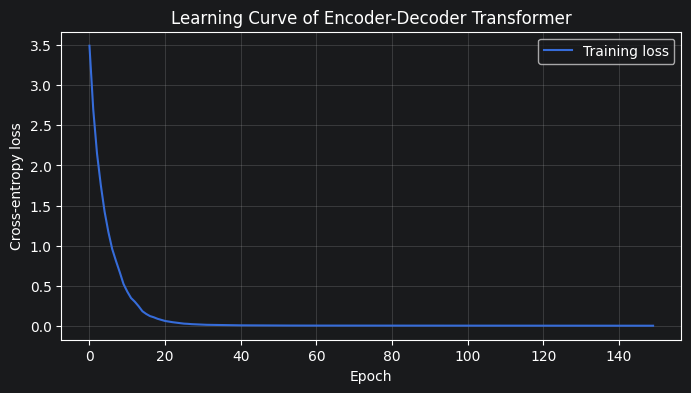

In [14]:
if HAS_MATPLOTLIB:
    plt.figure(figsize=(8, 4))
    plt.plot(loss_history, label='Training loss')
    plt.xlabel('Epoch')
    plt.ylabel('Cross-entropy loss')
    plt.title('Learning Curve of Encoder-Decoder Transformer')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
else:
    print('matplotlib is not installed, so only the numeric loss history is shown.')

## Step 13: Simple Inference (Autoregressive Generation)

To generate a translation, we:
1. Encode the source sequence.
2. Start the target sequence with `<SOS>` (0).
3. Repeatedly pass the current target sequence and the encoder output into the decoder to predict the next token.
4. Append the predicted token to the target sequence and repeat until `<EOS>` (1) is predicted or we reach the maximum length.

In [15]:
def translate(model, src_tokens, max_len=12):
    model.eval()
    with torch.no_grad():
        # check whether src_tokens[0] is an instance of str (string)
        #   if src_tokens is string (True) then it needs to extract its token through encode_tokens() before assigns to src_seq
        #   else, it directly assigns src_tokens as src_seq
        if isinstance(src_tokens[0], str):
            src_seq = encode_tokens(src_tokens, src_vocab)
        else:
            src_seq = src_tokens

        # Encoder part
        # Create and initialize tensor object `src` as input object
        src = torch.tensor([src_seq], dtype=torch.long)

        # word embedding
        enc_out = model.src_embedding(src)
        # enter encoder blocks
        for enc_block in model.encoder_blocks:
            enc_out = enc_block(enc_out)

        # Decoder part
        # Create and initialize tensor object `tgt` as by filling `<SOS>` tag
        #   to tells the decoder blocks to start generating at first words
        tgt = torch.tensor([[tgt_vocab['<SOS>']]], dtype=torch.long)
        # Create and initialize to store the generated tokens
        generated_tokens = []

        # keep in loop until it reach max_len
        for _ in range(max_len):
            # entering word embedding
            dec_out = model.tgt_embedding(tgt)
            # Create and initalize causal mask as requirement for decoder blocks
            mask = model.create_causal_mask(tgt.shape[1], tgt.device)

            # enter decoder blocks
            for dec_block in model.decoder_blocks:
                dec_out = dec_block(dec_out, enc_out, mask)

            # Get the predicted_score (logits) from dec_out
            logits = model.classifier(dec_out[:, -1, :])
            # take the predicted next_token using greedy decoding
            next_token = torch.argmax(logits, dim=-1).item()

            # if the next_token is `<EOS>`, break and stop the for loops
            if next_token == tgt_vocab['<EOS>']:
                break

            # append the next_token in arrays[] and store in words
            generated_tokens.append(id_to_tgt[next_token])
            # store the `token ID` of generated next_token in `tgt`
            tgt = torch.cat([tgt, torch.tensor([[next_token]], dtype=torch.long)], dim=1)
                
    return generated_tokens

# Test on a word-based example
# TO-DO: use unseen input to evaluate the real the encoder-decoder transformer
test_src = ['the', 'small', 'cat', 'sat', 'on', 'the', 'warm', 'mat']
print("Input:", ' '.join(test_src))
print("Model:", ' '.join(translate(model, test_src)))

Input: the small cat sat on the warm mat
Model: le petit chat est assis sur le tapis chaud


## Summary

- The **Encoder** uses bidirectional attention to encode the source sequence into continuous representations.
- The **Decoder** uses causal masked self-attention to read its own generated tokens, and **cross-attention** to read the encoder's output.
- `forward()` combines both for training (using teacher forcing, where we supply the ground truth shifted right).
- Inference must be done autoregressively: generating one token at a time, feeding the generated output back as input into the decoder.